# Starter Notebook - Spot The mask

This notebook is going to run through all the steps in creating a submission for the [SPOT THE MASK contest](https://zindi.africa/competitions) on Zindi. If you want to skip the explanations, scroll down to the end for a minimal example submission from scratch in 10 lines of code.

# High level Understanding.

For this challenge, we were given a train dataset that contains 1800+ images of people wearing mask or not. The objective of this challenge is to create an image classification machine learning model to accurately predict the likelihood that an image contains a person wearing a face mask, or not

The stakeholders believe your machine learning solution will help policymakers, law enforcement, hospitals, and even commercial businesses ensure that masks are being worn appropriately in public, and that The solutions can help in the battle to reduce community transmission of COVID-19.

This tutorial will give you some insight on how it is done.

# Setup

Before we can start modelling, we need to get the data somehow. Since this example is running in Colab, you have several options:
- Upload everything through the 'Files' tab on the left
- Upload the files to your Google Drive and then use the 'Mount Drive' option to oad your drive like and external hard drive.
- Download the files directly from Kaggle [here](https://www.kaggle.com/datasets/victorolufemi/spot-the-mask-challenge/data) or better still use the kaggle library to get it in smoothly.

I've uploaded the two CSV files manually, since they're small. The images are only ~200MB zipped, but why waste your home internet? You can then use the line of code below to download the file:

In [1]:
import os
import kagglehub

# # Download latest version
path = kagglehub.dataset_download("victorolufemi/spot-the-mask-challenge")

# print("Path to dataset files:", path)

In [2]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch

The data comes in a zip file. This command extracts it into the 'images' folder. The '-q' option stops it listing all the files and keeps our notebook looking tidy.

Normally, Colab is great in that everything you need to get started is present. However, we want our libraries updated, and to make sure we have the latest (best) of our major libraries. Below, we install FastAI and Timm.

# Installing Libraries

### About FastAI

FastAI is an open-source deep learning library built on top of PyTorch that provides a high-level API for researchers and practitioners to build, train, and deploy machine learning models efficiently, particularly for computer vision, natural language processing, and tabular data analysis. It includes pre-trained models, data augmentation tools, and support for large datasets and distributed training.

Before you grin, I really love this library because it can serve as a very high level one where many things look abstracted and it can go very very low level where you can do lots of crazy stuff if you know what you are doing.

### About Timm

The Timm library is a popular open-source computer vision library built on top of PyTorch. It is created by Ross Wightman contains collection of SOTA computer vision models, layers, utilities, optimizers, schedulers, data-loaders, augmentations and also training/validating scripts with ability to reproduce ImageNet training results.

In [3]:
%%capture
!pip install timm
!pip install fastai
!pip install pytorch-metric-learning 
!pip install --upgrade fastprogress fastai

With installations out the way, we can load in some libraries. It's good practice to keep all your imports right at the top. THe most important ones here are pandas (for making it easy to work with tabular data) and fastai (for the actual deep learning).

In [4]:
import pandas as pd
import timm
import warnings
from fastai.vision.all import * #import everthing from vision
warnings.filterwarnings('ignore')

Import FastAI to check out your version to avoid disparities. As at the time of writing mine was 2.8.6.

In [5]:
import fastai
print(fastai.__version__ )

2.8.7


In [6]:
from fastai.vision.all import *
from fastai.callback.mixup import MixUp, CutMix
from fastai.callback.tracker import SaveModelCallback

# A look at the dataset

The labels come as a CSV file. For convenience and to check out the data, we can load it into a dataframe using pandas.

If you are getting an error, it means you've not uploaded the CSV files. Download the CSV files from [here](https://www.kaggle.com/datasets/victorolufemi/spot-the-mask-challenge/data) and upload them through the left tab of this notebook. Or check the code below the kaggle one to be sure thing run smoothly.

In [7]:
train_df = pd.read_csv("/kaggle/input/datasets/victorolufemi/spot-the-mask-challenge/train_labels.csv")
ss = pd.read_csv("/kaggle/input/datasets/victorolufemi/spot-the-mask-challenge/SampleSubmission.csv")

In [8]:
train_df.head()

,image,target
0,tfymlmdkpzkqdjhdxyhnoeuqszxphw.jpg,0
1,rxgismgsvmaayzjarbfjaljhqmpbrt.jpg,1
2,uuzshfrhkgrkolhwdvliqauzulurnz.jpg,0
3,mjspxsagzusaznvnyxgamtrlqkqklp.jpg,0
4,rlbmuajgezfiddjzlyeoupxpqubkpt.jpg,1


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   1308 non-null   object
 1   target  1308 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 20.6+ KB


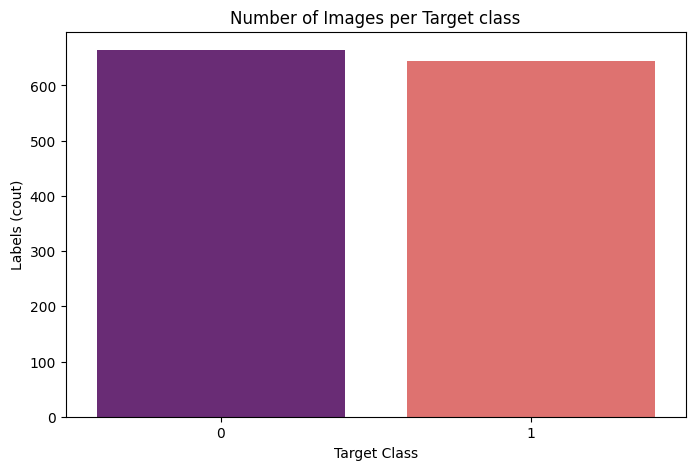

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# If you want to see variation in image counts per target
target_counts = train_df['target'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='magma')
plt.title("Number of Images per Target class")
plt.xlabel("Target Class")
plt.ylabel("Labels (cout)")
plt.show()



In [11]:
train_df['target'].value_counts()

target
0    664
1    644
Name: count, dtype: int64

## Getting the data ready for the model
###### Creating your Data block

In [12]:
img_path = "/kaggle/input/datasets/victorolufemi/spot-the-mask-challenge/images/images/"

In [13]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_x=ColReader('image', pref=img_path),
    get_y=ColReader('target'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=1.5, do_flip=True, flip_vert=False, max_rotate=15.0) # Augmentation boostée
).dataloaders(train_df, bs=16, num_workers=0)

In [14]:
#  test 'convnext_tiny' or 'vit_tiny_patch16_224'
model_name = 'convnext_tiny' #  

learn = vision_learner(
    dls, 
    model_name, 
    #loss_func=FocalLoss(gamma=2.0),
    metrics=[error_rate, accuracy],
    cbs=[
    #     MixUp(alpha=0.2),        # MixUp 
    #     #CutMix(alpha=1.0),       # CutMix 
         SaveModelCallback(monitor='valid_loss')
    ],
    # loss_func=LabelSmoothingCrossEntropy() # penalize my model as to it to accurate to be sure
).to_fp16() # Utilise la précision mixte pour entraîner plus vite (si le GPU le supporte)

learn.fine_tune(20)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.318319,0.175339,0.038314,0.961686,00:36


Better model found at epoch 0 with valid_loss value: 0.17533928155899048.


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.127983,0.167505,0.019157,0.980843,00:26
1,0.131940,0.116116,0.015326,0.984674,00:22
2,0.106926,0.116067,0.026820,0.973180,00:22
3,0.108158,0.180183,0.019157,0.980843,00:22
4,0.092117,0.120972,0.019157,0.980843,00:22
5,0.075648,0.160339,0.019157,0.980843,00:22
6,0.073962,0.150071,0.022989,0.977012,00:23
7,0.066730,0.139665,0.022989,0.977012,00:24
8,0.053859,0.144443,0.022989,0.977012,00:24
9,0.039236,0.100425,0.022989,0.977012,00:24


Better model found at epoch 0 with valid_loss value: 0.16750477254390717.
Better model found at epoch 1 with valid_loss value: 0.11611634492874146.
Better model found at epoch 2 with valid_loss value: 0.11606726795434952.
Better model found at epoch 9 with valid_loss value: 0.10042469203472137.
Better model found at epoch 10 with valid_loss value: 0.09575587511062622.
Better model found at epoch 12 with valid_loss value: 0.09051033854484558.
Better model found at epoch 14 with valid_loss value: 0.07467465102672577.


## Evaluation et interpretation

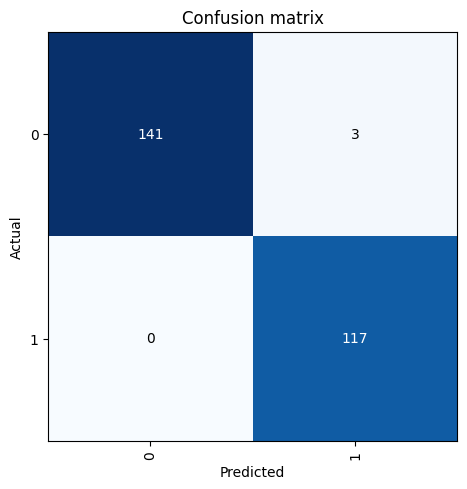

In [15]:
interp = ClassificationInterpretation.from_learner(learn)

interp.plot_confusion_matrix()

#### Deep Dive into Data Augmentation.

Data augmentation is a technique used in deep learning to increase the size of the training dataset by applying various transformations to the original images. This can help to reduce overfitting and improve the generalization performance of the model.

For image data, data augmentation techniques include rotation, scaling, flipping, cropping, and changing the brightness, contrast, and hue of the images. By applying these transformations to the training data, the model can learn to recognize objects and patterns from a wider range of perspectives and lighting conditions.

Data augmentation can be implemented using various libraries and frameworks, not limited to FastAI and PyTorch, which provide pre-defined functions for applying common transformations.

In FastAI you can customize by defining the item_tfms and the batch_tfms

###### Example 1: Padding Images


# Time for training!

Now it's time to train a model. We're going to take advantage of transfer learning, and start with a nice pretrained model. There are many to choose from as listed above in the [timm library](https://github.com/huggingface/pytorch-image-models). Here, we'll use a ResNet18.

There are fancier models that might take longer to train but can give better accuracy - check out the minimal example at the end of this notebook to see another model in action.

If you want to know which models are the best, check out this notebook from Jeremy Howard, the founder of FastAI. https://www.kaggle.com/code/jhoward/which-image-models-are-best/

Creating a 'learner' with our chosen model architecture is as simple as:

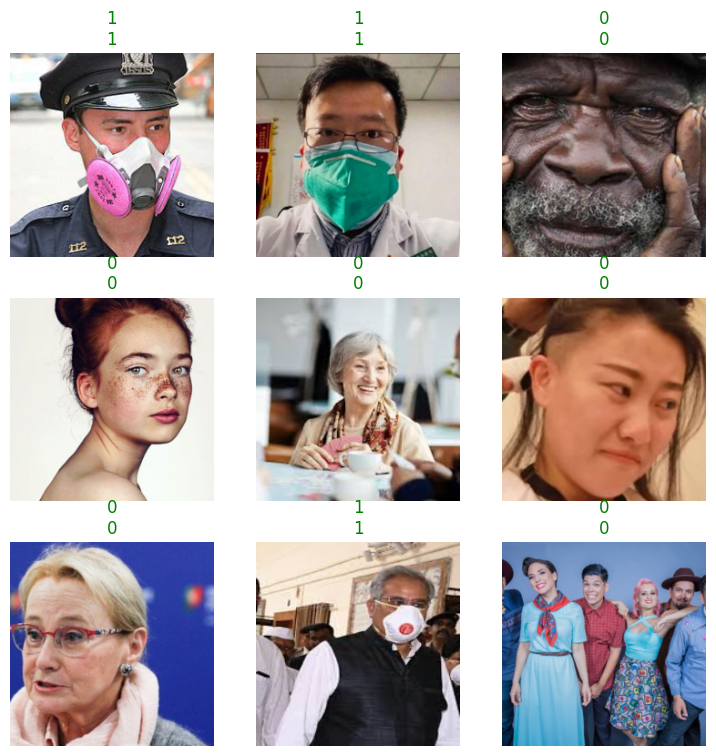

In [16]:
learn.show_results()

###### Check the Confusion Matrix

A confusion matrix is a useful tool for evaluating the performance of a classification model, as it provides more detailed information than a simple accuracy score. It can help identify clases where the model is making more errors, such as misclassifying one class as another.

In FastAI, you can generate a confusion matrix for a trained model using the interp.plot_confusion_matrix() method. This method takes the validation dataset as input and generates a graphical representation of the confusion matrix.

###### Plot the Top Losses

In FastAI, learn.plot_top_losses() is a method that allows you to visualize the samples in a validation set that the model had the most trouble predicting.

When called, learn.plot_top_losses() will display a grid of images from the validation set that were most misclassified by the model. These images are typically sorted by the model's loss values, with the highest loss images appearing at the top of the grid.

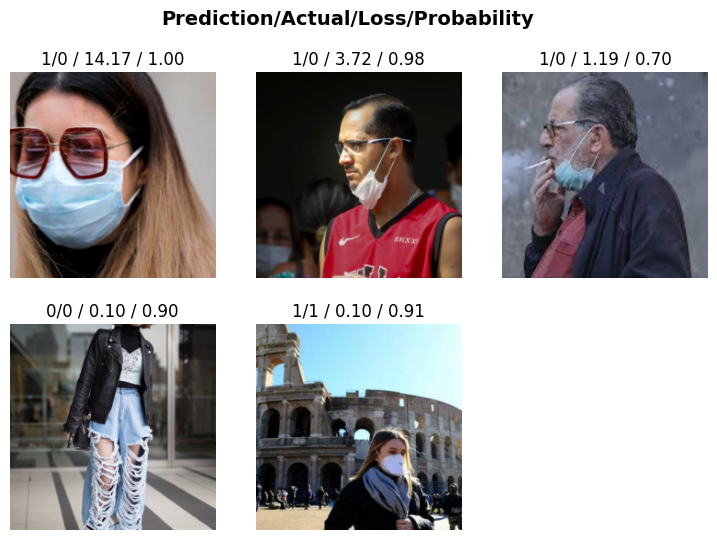

In [17]:
## plot_top_losses which shows us the images with the highest loss in our dataset
interp.plot_top_losses(5)

# Improving prediction score

In [18]:
ss.tail() #see what the test set looks like

,image,target
504,zpfhbgixcctxylnihhrepjgcmjksvf.jpg,0
505,zuignwckjykxefmpubjpjefvhghaoi.jpg,0
506,zuxvwdblfwjpibjexgfglpyreqslhs.jpg,0
507,zvyajojutzgqumdjfxxkpiuuxeefyy.jpg,0
508,zynasgxnxnzqaallnvkthegctommtu.jpg,0


To make predictions, we need to create the test dataset in a format that fastAI can take in, we do this like so:

In [19]:
tdl = dls.test_dl(ss) # quicly create test data loader

Now we can get predictions:

In [20]:

test_preds_, test_labels_tta = learn.get_preds(dl=tdl) #Get Preds

In [21]:

# What do these look like?
test_preds_[0] # The first prediction

tensor([0.9975, 0.0025])

The predictions take the firm [P(no_mask), P(mask)]. We want the second one, and we can add it to our target column like so:

In [22]:
train_df.tail()

,image,target
1303,hxjwafskxmlfaotwaklzuwuccsbxfu.jpg,0
1304,oyodauphffgmzmvqlykcfvmyxartok.jpg,1
1305,uppvtemhkneqggtbfubeccqjvyefiw.png,1
1306,mzjjvzkzvqmyukzsegtoktaslejcdz.jpg,0
1307,dbjdjyhnbvblwhhnfzaahzhdezbbib.jpg,0


Preparing your Submission

In [23]:
submission = ss.copy()
submission.head()

,image,target
0,aadawlxbmapqrblgxyzarhjasgiobu.png,0
1,abpxvdfyhaaohzcrngcucmhffwizxs.jpg,0
2,aclkjfvackiieiznzfcwienplielrj.jpg,0
3,aelkivmayxgsdjosiibfgmkvfrjvjk.jpg,0
4,aelzzshpfxerelefnkatpczktuxjln.jpg,0


In [24]:
submission['target'] = [float(p[1]) for p in test_preds_] # we want p(Mask) for our submission, so we'll look at the second number in each prediction with p[1]
submission.head()

,image,target
0,aadawlxbmapqrblgxyzarhjasgiobu.png,0.002502
1,abpxvdfyhaaohzcrngcucmhffwizxs.jpg,0.000019
2,aclkjfvackiieiznzfcwienplielrj.jpg,1.000000
3,aelkivmayxgsdjosiibfgmkvfrjvjk.jpg,0.999750
4,aelzzshpfxerelefnkatpczktuxjln.jpg,0.001394


In [25]:
# Save the file
submission.to_csv('starter_nb_baseline.csv', index=False)

In [26]:
test_preds_tta, test_labels_tta = learn.tta(dl=tdl) #TTA

epoch,train_loss,valid_loss,error_rate,accuracy,time


<div></div>

In [27]:
submission['target'] = [float(p[1]) for p in test_preds_tta]
submission.head()

,image,target
0,aadawlxbmapqrblgxyzarhjasgiobu.png,0.553748
1,abpxvdfyhaaohzcrngcucmhffwizxs.jpg,0.000070
2,aclkjfvackiieiznzfcwienplielrj.jpg,1.000000
3,aelkivmayxgsdjosiibfgmkvfrjvjk.jpg,0.993579
4,aelzzshpfxerelefnkatpczktuxjln.jpg,0.000747


In [28]:
# Save the file
submission.to_csv('starter_nb_baseline_with_TTA.csv', index=False)

In [29]:
# Average of two sets of predictions
preds1 = pd.read_csv('starter_nb_baseline.csv')
preds2 = pd.read_csv('starter_nb_baseline_with_TTA.csv')
av_preds = pd.DataFrame({
    'image':preds1['image'],
    'target': 0.5*preds1['target'] + 0.5*preds2['target']
}) 

av_preds.to_csv('zindi-submission-26.csv', index=False)

# Exercise: Run the minimal example below and combine those predictions with the tta submission from above

# Exercise: If one model is substantailly better, we may want it's predictins to count more towards the final prodiction.
#          Try to use 0.8*good_predictions + 0.2*other_predictions to skey your ensemble predicitons towards the better model's outputs.

In [30]:
learn.export('model.pkl')